# Introduction

This notebook accompanies the thesis **“SQL-Centric Optimization of Backtesting and Feature Engineering for Trading Strategies: Benchmarking Against Python Using Vietnamese Stock Market Data.”**

**Objective.** The study evaluates how trading features and backtests can be computed in **SQL** versus **Python**.

**Scope.** Daily **OHLCV** data for Vietnamese equities (2006–2025) are used.

## Data & Assumptions

**Data fields.** `symbol, date, open, high, low, close, volume`.

**Calendar.** Dates are aligned to the VN trading calendar; weekends and official holidays are excluded.

**Coverage and bias.**
- Survivorship bias may exist if delisted tickers are absent.
- Corporate actions (splits/dividends) are not adjusted in this.

**Purpose.** This data section establishes a **single, canonical input** used by both SQL and Python pipelines to ensure fair comparison.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
from pathlib import Path
pio.renderers.default = "notebook"

In [2]:
PATH = Path(r"C:\Users\Nguyen Thao\Downloads\data\out\prices_all.csv")
prices = pd.read_csv(
    PATH,
    parse_dates=["date"],
    dtype={"symbol": "string"},
    dayfirst=True
)
prices = prices.sort_values(["symbol", "date"], ignore_index=True)

# Show first 5 rows nicely formatted as a table
display(prices.head())

,symbol,date,open,high,low,close,volume
0,BID,2014-01-24,18.8,19.5,18.5,18.8,"5,279,630,000.00"
1,BID,2014-01-27,18.8,18.8,18.1,18.8,"622,914,000.00"
2,BID,2014-02-06,18.4,18.4,17.6,18.4,"278,430,000.00"
3,BID,2014-02-07,17.6,17.6,16.5,17.6,"302,520,000.00"
4,BID,2014-02-10,16.6,17.2,16.2,16.6,"14,165,667,000.00"


## Exploratory Data Summary

The following quick EDA validates the dataset used for benchmarking:

- row and column counts,
- number of unique symbols,
- date range,
- missing-value report per column,
- descriptive statistics for numeric fields.

In [13]:
# 1. General dataset summary
eda_summary = pd.DataFrame({
    "Rows": [prices.shape[0]],
    "Columns": [prices.shape[1]],
    "Missing values (total)": [prices.isna().sum().sum()],
    "Unique symbols": [prices["symbol"].nunique()],
    "Date range": [f"{prices['date'].min().date()} → {prices['date'].max().date()}"]
})
display(eda_summary)

# 2. Missing values per column
display(prices.isna().sum().to_frame("Missing Values"))

# 3. Numeric stats
display(prices.describe().T)

,Rows,Columns,Missing values (total),Unique symbols,Date range
0,107294,7,0,30,2000-07-28 → 2025-10-03


,Missing Values
symbol,0
date,0
open,0
high,0
low,0
close,0
volume,0


,count,mean,min,25%,50%,75%,max,std
date,107294,2017-10-05 03:28:39.440043520,2000-07-28 00:00:00,2013-11-15 00:00:00,2018-08-07 00:00:00,2022-03-07 00:00:00,2025-10-03 00:00:00,NaN
open,107294.0,51.591537,4.55,22.95,38.7,66.3,665.0,43.57829
high,107294.0,52.329233,4.84,23.3,39.2,67.1,672.0,44.208687
low,107294.0,50.963384,0.1,22.65,38.2,65.5,665.0,43.107711
close,107294.0,51.591537,4.55,22.95,38.7,66.3,665.0,43.57829


## Price Visualization

A **candlestick chart** provides a first view of trend and volatility for a selected ticker (e.g., `VNM`):

- Green candles: close ≥ open (bullish days).
- Red candles: close < open (bearish days).
- Bodies show open–close ranges; wicks show intraday highs and lows.

This plot serves as a sanity check before feature engineering and backtesting.

In [46]:
# Filter data for VNM
df_vnm = prices.query("symbol == 'VNM'")

# Create candlestick chart
fig = go.Figure(go.Candlestick(
    x=df_vnm["date"],
    open=df_vnm["open"],
    high=df_vnm["high"],
    low=df_vnm["low"],
    close=df_vnm["close"]
))
fig.update_layout(
    title="VNM Candlestick",
    xaxis_title="Date",
    yaxis_title="Price",
    xaxis_rangeslider_visible=False
)
fig.show()

# Methodology

The methodology follows three layers:

1) **Feature Engineering.** Indicators are computed with vectorized Python code and **mirrored in SQL** (views/UDFs).  
2) **Backtesting.** Strategies consume those features under a common execution model.  
3) **Benchmarking.** SQL and Python pipelines are compared on identical inputs and configuration.

# Simple vs Log Returns

**Simple return:** It measures the percentage change in price from one period to the next.

$$
R_t = \frac{P_t}{P_{t-1}} - 1
$$

**Logarithmic return:** Log returns are additive over time and often used in quantitative finance.


$$
r_t = \ln\!\left(\frac{P_t}{P_{t-1}}\right)
$$



symbol       date  close  simple_return
   BID 2014-01-24   18.8            NaN
   BID 2014-01-27   18.8       0.000000
   BID 2014-02-06   18.4      -0.021277
   BID 2014-02-07   17.6      -0.043478
   BID 2014-02-10   16.6      -0.056818
   BID 2014-02-11   17.0       0.024096
   BID 2014-02-12   16.9      -0.005882
   BID 2014-02-13   16.8      -0.005917
   BID 2014-02-14   16.6      -0.011905
   BID 2014-02-17   16.8       0.012048


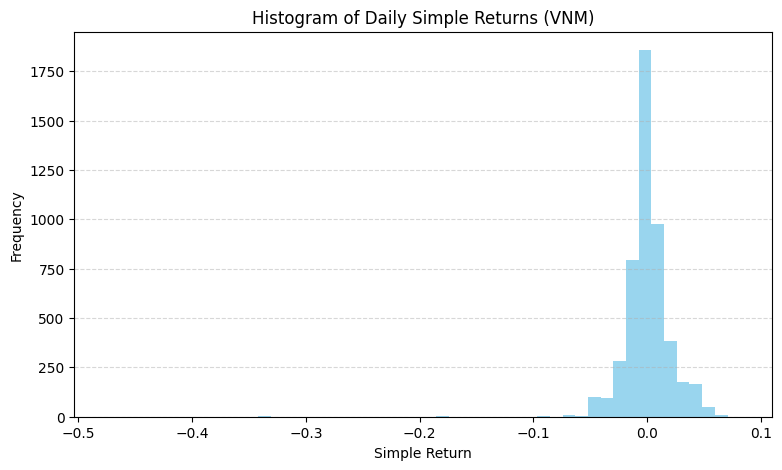

In [53]:
# --- Simple Return ---
prices["simple_return"] = prices.groupby("symbol")["close"].pct_change()
print(prices[["symbol","date","close","simple_return"]].head(10).to_string(index=False))

d = prices[prices["symbol"]=="VNM"].sort_values("date")
d["simple_return"].dropna().plot.hist(bins=50, color="skyblue", alpha=0.85, figsize=(9,5),
                                      title="Histogram of Daily Simple Returns (VNM)")
plt.xlabel("Simple Return"); plt.ylabel("Frequency"); plt.grid(axis="y", ls="--", alpha=0.5)
plt.show()


symbol       date  close  log_return
   BID 2014-01-24   18.8         NaN
   BID 2014-01-27   18.8    0.000000
   BID 2014-02-06   18.4   -0.021506
   BID 2014-02-07   17.6   -0.044452
   BID 2014-02-10   16.6   -0.058496
   BID 2014-02-11   17.0    0.023811
   BID 2014-02-12   16.9   -0.005900
   BID 2014-02-13   16.8   -0.005935
   BID 2014-02-14   16.6   -0.011976
   BID 2014-02-17   16.8    0.011976


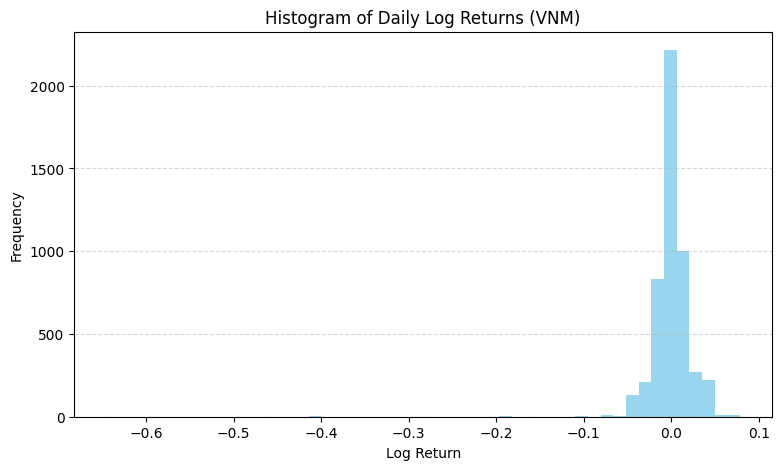

In [55]:
# --- Log Return ---
prices["log_return"] = prices.groupby("symbol")["close"] \
                             .transform(lambda s: np.log(s).diff())
print(prices[["symbol","date","close","log_return"]].head(10).to_string(index=False))

d = prices[prices["symbol"]=="VNM"].sort_values("date")
d["log_return"].dropna().plot.hist(bins=50, color="skyblue", alpha=0.85, figsize=(9,5),
                                   title="Histogram of Daily Log Returns (VNM)")
plt.xlabel("Log Return"); plt.ylabel("Frequency"); plt.grid(axis="y", ls="--", alpha=0.5)
plt.show()

### Cumulative Returns

Cumulative return measures the total growth of an investment over time.  
It can be defined in compounding form:

$$
CR_t = \prod_{i=1}^{t}(1+R_i) - 1
$$

where \(Ri\) is the simple return at period \(i\).

In the special case where only the initial and final prices are considered, it simplifies to:

$$
CR_t = \frac{P_t}{P_0} - 1
$$

symbol       date  close  cumulative_return
   BID 2014-01-24   18.8           0.000000
   BID 2014-01-27   18.8           0.000000
   BID 2014-02-06   18.4          -0.021277
   BID 2014-02-07   17.6          -0.063830
   BID 2014-02-10   16.6          -0.117021
   BID 2014-02-11   17.0          -0.095745
   BID 2014-02-12   16.9          -0.101064
   BID 2014-02-13   16.8          -0.106383
   BID 2014-02-14   16.6          -0.117021
   BID 2014-02-17   16.8          -0.106383


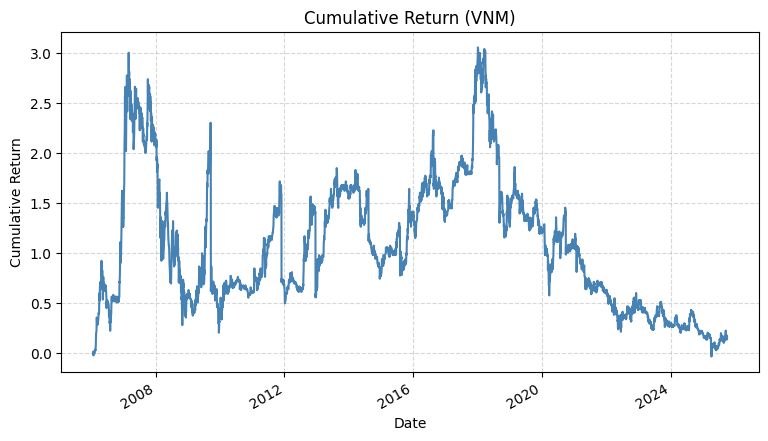

In [56]:
# --- Cumulative Return ---
prices["cumulative_return"] = prices.groupby("symbol")["close"] \
                                    .transform(lambda s: s / s.iloc[0] - 1)
print(prices[["symbol","date","close","cumulative_return"]].head(10).to_string(index=False))

d = prices[prices["symbol"]=="VNM"].sort_values("date")
d.plot(x="date", y="cumulative_return", figsize=(9,5), legend=False,
       title="Cumulative Return (VNM)", color="steelblue")
plt.xlabel("Date"); plt.ylabel("Cumulative Return"); plt.grid(ls="--", alpha=0.5)
plt.show()

### Annualized Return

Annualized return scales the investment performance to a yearly horizon.  

**Geometric definition (exact):**
$$
AR = \left(\prod_{i=1}^{n}(1+R_i)\right)^{\tfrac{252}{n}} - 1
$$

where Ri are the daily returns and \(n\) is the number of trading days observed.

**Approximation (arithmetic):**
$$
AR \approx \bar{R}_{daily} \times 252
$$

**From log returns (equivalent):**
$$
AR = \exp\!\big(\overline{r_{\log}} \cdot 252\big) - 1
$$

In [128]:
g = prices.groupby("symbol", sort=False)["close"]
ann = (
    g.agg(first="first", last="last", n="size")
     .assign(annualized=lambda x: (x["last"]/x["first"])**(252/x["n"]) - 1)
     .reset_index()[["symbol","annualized"]]
)
print(ann.head(10).to_string(index=False)) 

symbol  annualized
   BID    0.067472
   BVH    0.009372
   CTG    0.015448
   DGC    0.080840
   DXG   -0.054509
   FPT   -0.075838
   GAS    0.029413
   GEX    0.097147
   GMD    0.019135
   HCM   -0.012421


# Volatility

Volatility measures the dispersion of daily returns.  
It is computed as the standard deviation of daily returns:

$$
\sigma_{daily} = \text{Std}(R_t)
$$

Annualized volatility assumes 252 trading days:

$$
\sigma_{annual} = \sigma_{daily} \times \sqrt{252}
$$

A rolling 20-day window can be used to observe short-term changes in risk.

In [61]:
# --- Volatility (daily & annualized) ---
# Log returns (index-safe)
prices["log_return"] = prices.groupby("symbol", sort=False)["close"] \
                             .transform(lambda s: np.log(s).diff())

# Daily volatility per symbol  -> DataFrame
vol = (
    prices.dropna(subset=["log_return"])
          .groupby("symbol", sort=False)["log_return"]
          .std()
          .reset_index(name="daily_vol")
)

# Annualized
vol["annual_vol"] = vol["daily_vol"] * np.sqrt(252)

# Preview table
print(vol.head(10).to_string(index=False))

# Optional: print one symbol
sym = "VNM"
dv = vol.loc[vol["symbol"]==sym, "daily_vol"].iloc[0]
av = vol.loc[vol["symbol"]==sym, "annual_vol"].iloc[0]
print(f"Daily Volatility ({sym}): {dv:.2%}")
print(f"Annualized Volatility ({sym}): {av:.2%}")

symbol  daily_vol  annual_vol
   BID   0.023025    0.365507
   BVH   0.024693    0.391991
   CTG   0.022309    0.354151
   DGC   0.029197    0.463484
   DXG   0.032071    0.509118
   FPT   0.023604    0.374708
   GAS   0.021215    0.336775
   GEX   0.027708    0.439852
   GMD   0.024710    0.392258
   HCM   0.030826    0.489354
Daily Volatility (VNM): 2.28%
Annualized Volatility (VNM): 36.12%


### Rolling Annualized Volatility

Annualized volatility measures the dispersion of returns, scaled to a yearly basis.  
The rolling version captures how risk evolves over different time windows.

For a rolling window of length \(n\):

$$
\sigma_{t}^{(n)} = \operatorname{Std}\!\big(\ell_{t-n+1}, \dots, \ell_t \big) \times \sqrt{252}
$$

where 
$$
\ell_t = \ln\!\left(\frac{P_t}{P_{t-1}}\right)
$$
is the log return.

In practice, we can compute and plot rolling volatilities with different horizons (e.g., 30-day, 60-day) to observe changing market risk levels.


symbol       date  log_return  roll_vol_30  roll_vol_60
   BID 2014-05-05    0.006349     0.226490     0.239896
   BID 2014-05-06   -0.012739     0.224894     0.240658
   BID 2014-05-07   -0.025975     0.205032     0.242286
   BID 2014-05-08    0.019545     0.207385     0.230963
   BID 2014-05-09   -0.059818     0.261867     0.232353
   BID 2014-05-12    0.013606     0.265919     0.228393
   BID 2014-05-13   -0.055570     0.298958     0.253078
   BID 2014-05-14    0.007117     0.297301     0.253874
   BID 2014-05-15    0.041673     0.327422     0.269054
   BID 2014-05-16   -0.034606     0.334928     0.275557


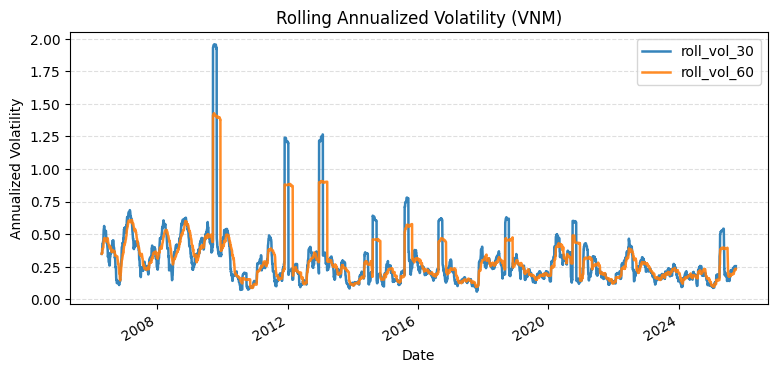

In [134]:
# --- Rolling Annualized Volatility---
prices = prices.sort_values(["symbol","date"]).reset_index(drop=True)
g = prices.groupby("symbol", sort=False)
prices["log_return"] = g["close"].transform(lambda s: np.log(s).diff())
prices["roll_vol_30"] = g["log_return"].transform(lambda s: s.rolling(30, min_periods=30).std()*np.sqrt(252))
prices["roll_vol_60"] = g["log_return"].transform(lambda s: s.rolling(60, min_periods=60).std()*np.sqrt(252))

mask = prices["roll_vol_30"].notna() & prices["roll_vol_60"].notna()
print(
    prices.loc[mask, ["symbol","date","log_return","roll_vol_30","roll_vol_60"]]
          .head(10).to_string(index=False)
)

# Visualize for VNM
sym = "VNM"
d = prices[prices["symbol"]==sym].sort_values("date").dropna(subset=["roll_vol_30","roll_vol_60"])
ax = d.plot(x="date", y=["roll_vol_30","roll_vol_60"], figsize=(9,4), lw=1.8, alpha=0.9,
            title=f"Rolling Annualized Volatility ({sym})")
ax.set_xlabel("Date"); ax.set_ylabel("Annualized Volatility"); ax.grid(axis="y", ls="--", alpha=0.4)
plt.show()


## Simple Moving Average (SMA)
$$
\mathrm{SMA}_n(t) = \frac{1}{n}\sum_{i=0}^{n-1} P_{t-i}
$$
- Arithmetic mean of the last n closes.  
- Smooths noise; longer n = slower but more stable trend.

symbol       date  close  SMA20  SMA50
   BID 2014-04-15   16.7 16.940 16.932
   BID 2014-04-16   16.5 16.935 16.886
   BID 2014-04-17   16.0 16.895 16.830
   BID 2014-04-18   16.1 16.830 16.784
   BID 2014-04-21   15.9 16.740 16.750
   BID 2014-04-22   15.5 16.640 16.728
   BID 2014-04-23   15.8 16.550 16.704
   BID 2014-04-24   15.8 16.480 16.682
   BID 2014-04-25   15.9 16.435 16.664
   BID 2014-04-28   15.7 16.380 16.646


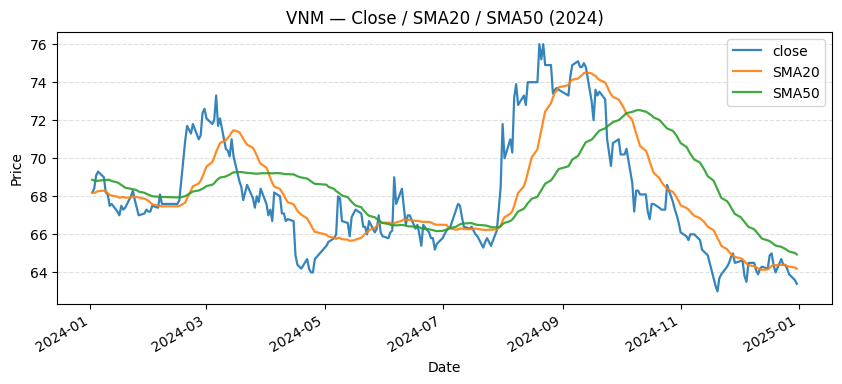

In [130]:
# SMA
g = prices.groupby("symbol")["close"]
prices["SMA20"] = g.transform(lambda s: s.rolling(20, min_periods=20).mean())
prices["SMA50"] = g.transform(lambda s: s.rolling(50, min_periods=50).mean())

# Preview rows (non-NaN)
mask = prices["SMA20"].notna() & prices["SMA50"].notna()
print(prices.loc[mask, ["symbol","date","close","SMA20","SMA50"]].head(10).to_string(index=False))

# Visualize VNM in 2024
SYM, START, END = "VNM", "2024-01-01", "2025-01-01"
d = prices[(prices["symbol"]==SYM) & (prices["date"]>=START) & (prices["date"]<END)].dropna(subset=["SMA50"])
d.plot(x="date", y=["close","SMA20","SMA50"], figsize=(10,4), linewidth=1.6, alpha=0.9,
       title=f"{SYM} — Close / SMA20 / SMA50 (2024)")
plt.xlabel("Date"); plt.ylabel("Price"); plt.grid(axis="y", ls="--", alpha=0.4); plt.show()

## Exponential Moving Average (EMA)

The EMA is a weighted moving average that gives higher importance to recent prices.  
It reacts faster than the simple moving average (SMA), making it useful for trend detection.

The recursive formula for EMA with window \(n\) is:

$$
\mathrm{EMA}_n(t) = \alpha P_t + (1-\alpha)\,\mathrm{EMA}_n(t-1), 
\quad \alpha = \frac{2}{n+1}
$$

- **EMA(12)**: short-term moving average.  
- **EMA(26)**: longer-term moving average.  
- The **crossover** between EMA12 and EMA26 is often used to identify trend shifts:
  - EMA12 > EMA26 → bullish momentum.  
  - EMA12 < EMA26 → bearish momentum.

symbol       date  close     EMA12     EMA26
   BID 2014-03-11   16.7 16.736772 17.072373
   BID 2014-03-12   16.6 16.715730 17.037382
   BID 2014-03-13   16.5 16.682541 16.997576
   BID 2014-03-14   16.5 16.654458 16.960718
   BID 2014-03-17   16.6 16.646080 16.933999
   BID 2014-03-18   16.6 16.638991 16.909258
   BID 2014-03-19   16.8 16.663761 16.901165
   BID 2014-03-20   17.4 16.777029 16.938116
   BID 2014-03-21   17.7 16.919024 16.994551
   BID 2014-03-24   17.5 17.008405 17.031992


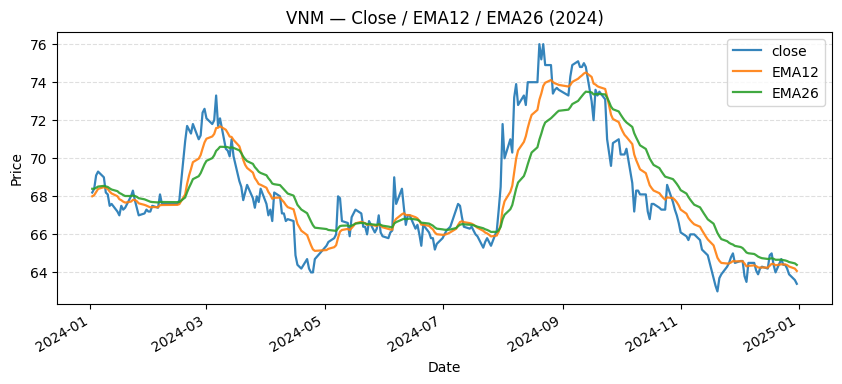

In [119]:
# Compute for whole market
g = prices.groupby("symbol")["close"]
prices["EMA12"] = g.transform(lambda s: s.ewm(span=12, adjust=False, min_periods=12).mean())
prices["EMA26"] = g.transform(lambda s: s.ewm(span=26, adjust=False, min_periods=26).mean())

# Preview rows (non-NaN)
mask = prices["EMA12"].notna() & prices["EMA26"].notna()
print(prices.loc[mask, ["symbol","date","close","EMA12","EMA26"]].head(10).to_string(index=False))

# Visualize VNM in 2024
d = prices[(prices["symbol"]==SYM) & (prices["date"]>=START) & (prices["date"]<END)].dropna(subset=["EMA26"])
d.plot(x="date", y=["close","EMA12","EMA26"], figsize=(10,4), linewidth=1.6, alpha=0.9,
       title=f"{SYM} — Close / EMA12 / EMA26 (2024)")
plt.xlabel("Date"); plt.ylabel("Price"); plt.grid(axis="y", ls="--", alpha=0.4); plt.show()

In [4]:
import numpy as np
import pandas as pd

def ema_sql_like(series, span, seed_mode="first", round_input=8):
    alpha = 2.0 / (span + 1)
    arr = series.to_numpy(dtype=float)
    if round_input is not None:
        arr = np.round(arr, round_input)
    res = np.zeros_like(arr)

    if seed_mode == "first":
        res[0] = arr[0]
    else:
        res[0] = np.mean(arr[:span])

    for i in range(1, len(arr)):
        res[i] = alpha * arr[i] + (1 - alpha) * res[i - 1]
        if round_input is not None:
            res[i] = np.round(res[i], round_input)
    return pd.Series(res, index=series.index)

# ==== TÍNH NHƯ SQL ====
prices = prices.sort_values(["symbol","date"])

# 1. EMA12 và EMA26 đã round trước khi trừ
prices["EMA12_sql"] = prices.groupby("symbol")["close"].transform(lambda x: ema_sql_like(x, 12))
prices["EMA26_sql"] = prices.groupby("symbol")["close"].transform(lambda x: ema_sql_like(x, 26))

# 2. MACD = EMA12 - EMA26, round tiếp
prices["MACD_sql"] = (prices["EMA12_sql"] - prices["EMA26_sql"]).round(8)

# 3. Signal = EMA9(MACD_sql), seed=first, round 8
prices["Signal_sql"] = prices.groupby("symbol")["MACD_sql"].transform(lambda x: ema_sql_like(x, 9, seed_mode="first"))

# 4. Hist = MACD - Signal
prices["Hist_sql"] = (prices["MACD_sql"] - prices["Signal_sql"]).round(8)

# Preview
print(prices.loc[prices["symbol"]=="BID", ["date","MACD_sql","Signal_sql","Hist_sql"]].head(15))

         date  MACD_sql  Signal_sql  Hist_sql
0  2014-01-24  0.000000    0.000000  0.000000
1  2014-01-27  0.000000    0.000000  0.000000
2  2014-02-06 -0.031909   -0.006382 -0.025527
3  2014-02-07 -0.120363   -0.029178 -0.091185
4  2014-02-10 -0.268065   -0.076955 -0.191109
5  2014-02-11 -0.348822   -0.131329 -0.217493
6  2014-02-12 -0.416095   -0.188282 -0.227813
7  2014-02-13 -0.472037   -0.245033 -0.227004
8  2014-02-14 -0.526442   -0.301315 -0.225127
9  2014-02-17 -0.547113   -0.350474 -0.196638
10 2014-02-18 -0.565050   -0.393390 -0.171661
11 2014-02-19 -0.580642   -0.430840 -0.149802
12 2014-02-20 -0.586240   -0.461920 -0.124320
13 2014-02-21 -0.560014   -0.481539 -0.078475
14 2014-02-24 -0.549039   -0.495039 -0.054000


## Moving Average Convergence Divergence (MACD)

The MACD is a momentum indicator based on the difference between two exponential moving averages (EMA).  
It highlights trend direction, momentum strength, and potential reversals.

Formally, with fast window \(n_f\), slow window \(n_s\), and signal window \(n_{sig}\):

$$
MACD_t = EMA_{t}^{(n_f)} - EMA_{t}^{(n_s)}
$$

$$
Signal_t = EMA_{t}^{(n_{sig})}(MACD_t)
$$

$$
Hist_t = MACD_t - Signal_t
$$

- **MACD line**: difference of short-term and long-term EMA (e.g., 12 vs. 26 days).  
- **Signal line**: smoothing of MACD (e.g., 9-day EMA)


symbol       date      MACD    Signal      Hist
   BID 2014-03-21 -0.075527 -0.228912  0.153385
   BID 2014-03-24 -0.023587 -0.187847  0.164260
   BID 2014-03-25  0.025353 -0.145207  0.170560
   BID 2014-03-26  0.031499 -0.109866  0.141364
   BID 2014-03-27  0.004046 -0.087084  0.091129
   BID 2014-03-28 -0.017509 -0.073169  0.055660
   BID 2014-03-31 -0.018243 -0.062184  0.043941
   BID 2014-04-01 -0.034564 -0.056660  0.022095
   BID 2014-04-02 -0.054935 -0.056315  0.001380
   BID 2014-04-03 -0.070269 -0.059106 -0.011163


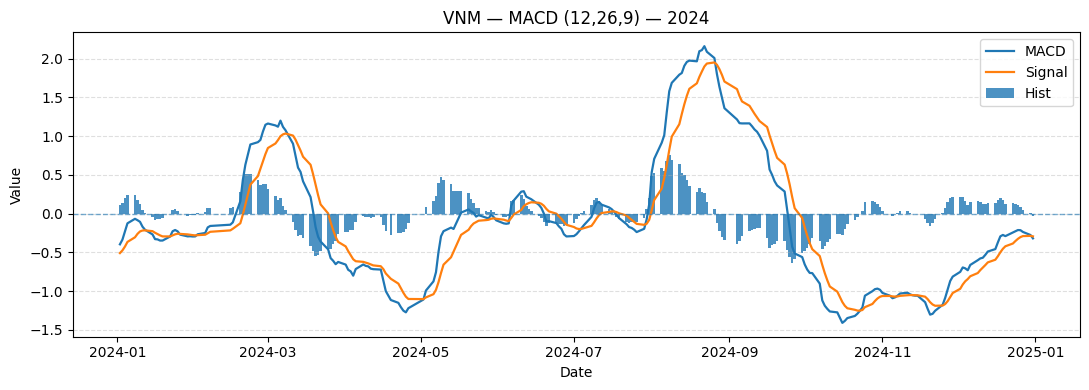

In [3]:
# --- MACD (12,26,9): market → preview → visualize VNM for 2024 ---
def ema(s, span): return s.ewm(span=span, adjust=False, min_periods=span).mean()

# 1) Compute for ALL symbols
g = prices.groupby("symbol")
prices["EMA12"]  = g["close"].transform(lambda s: ema(s, 12))
prices["EMA26"]  = g["close"].transform(lambda s: ema(s, 26))
prices["MACD"]   = prices["EMA12"] - prices["EMA26"]
prices["Signal"] = g["MACD"].transform(lambda s: ema(s, 9))
prices["Hist"]   = prices["MACD"] - prices["Signal"]

# 2) Preview (non-NaN)
mask = prices["Hist"].notna()
print(prices.loc[mask, ["symbol","date","MACD","Signal","Hist"]]
          .head(10).to_string(index=False))

# 3) Visualize VNM in 2024 only
sym, start, end = "VNM", pd.Timestamp("2024-01-01"), pd.Timestamp("2025-01-01")
d = (prices[(prices["symbol"]==sym) & (prices["date"]>=start) & (prices["date"]<end)]
            .dropna(subset=["Hist"]).sort_values("date"))

plt.figure(figsize=(11,4))
plt.bar(d["date"], d["Hist"], width=1.0, alpha=0.8, label="Hist")
plt.plot(d["date"], d["MACD"],  lw=1.6, label="MACD")
plt.plot(d["date"], d["Signal"], lw=1.6, label="Signal")
plt.axhline(0, ls="--", lw=1, alpha=0.6); plt.grid(axis="y", ls="--", alpha=0.4)
plt.title(f"{sym} — MACD (12,26,9) — 2024")
plt.xlabel("Date"); plt.ylabel("Value"); plt.legend(); plt.tight_layout(); plt.show()


## Relative Strength Index (RSI, Wilder)

First define price changes:

$$
\Delta P_t = P_t - P_{t-1}, 
\quad U_t = \max(\Delta P_t, 0), 
\quad D_t = \max(-\Delta P_t, 0)
$$

Wilder’s smoothed mean (RMA):

$$
RMA_n(X)_t = RMA_n(X)_{t-1} + \frac{1}{n}\Big( X_t - RMA_n(X)_{t-1} \Big)
$$

Then RSI is:

$$
RSI_n(t) = 100 - \frac{100}{1 + \frac{RMA_n(U)_t}{RMA_n(D)_t}}
$$

- Typical window: \(n = 14\).  
- RSI > 70 → overbought, RSI < 30 → oversold.  
- Divergences may indicate potential reversals.


symbol       date  RSI14_Wilder
   BID 2014-02-24     23.076923
   BID 2014-02-25     23.076923
   BID 2014-02-26     23.076923
   BID 2014-02-27     23.076923
   BID 2014-02-28     28.040473
   BID 2014-03-03     30.456743
   BID 2014-03-04     27.476049
   BID 2014-03-05     26.543534
   BID 2014-03-06     26.543534
   BID 2014-03-07     26.543534


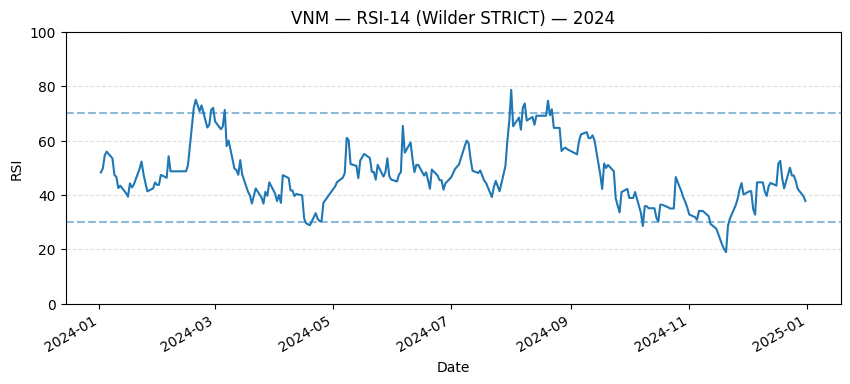

In [22]:
n = 14
g = prices.groupby("symbol", sort=False)

def rsi_wilder_strict(close: pd.Series, n: int = 14) -> pd.Series:
    # 1) Delta / Gain / Loss
    delta = close.diff()
    gain  = delta.clip(lower=0)
    loss  = (-delta).clip(lower=0)

    # 2) Khởi tạo SMA cho n phiên đầu tiên (Wilder gốc)
    avg_gain = gain.rolling(n, min_periods=n).mean()
    avg_loss = loss.rolling(n, min_periods=n).mean()

    # 3) Wilder smoothing đệ quy từ kỳ n+1
    for i in range(n+1, len(close)):
        avg_gain.iat[i] = (avg_gain.iat[i-1]*(n-1) + gain.iat[i]) / n
        avg_loss.iat[i] = (avg_loss.iat[i-1]*(n-1) + loss.iat[i]) / n

    # 4) RS & RSI (tránh chia 0 để không phát warning)
    ag = avg_gain.to_numpy(float)
    al = avg_loss.to_numpy(float)
    rs = np.divide(ag, al, out=np.zeros_like(ag), where=(al != 0))

    rsi = 100 - 100/(1 + rs)
    # Biên: AvgLoss=0 -> 100; AvgLoss=0 & AvgGain=0 -> 50
    rsi[(al == 0) & (ag > 0)] = 100.0
    rsi[(al == 0) & (ag == 0)] = 50.0

    return pd.Series(rsi, index=close.index)

# --- Tính RSI strict cho toàn bộ symbol ---
prices["RSI14_Wilder"] = g["close"].transform(lambda s: rsi_wilder_strict(s, n))

# preview a few non-NaN rows
m = prices["RSI14_Wilder"].notna()
print(prices.loc[m, ["symbol","date","RSI14_Wilder"]].head(10).to_string(index=False))

# visualize VNM for 2024
sym, start, end = "VNM", "2024-01-01", "2025-01-01"
d = prices[(prices["symbol"]==sym) & (prices["date"]>=start) & (prices["date"]<end)] \
        .dropna(subset=["RSI14_Wilder"]).sort_values("date")

d.plot(x="date", y="RSI14_Wilder", figsize=(10,4), legend=False,
       title=f"{sym} — RSI-14 (Wilder STRICT) — 2024")
plt.axhline(70, ls="--", alpha=0.5); plt.axhline(30, ls="--", alpha=0.5)
plt.ylim(0,100); plt.xlabel("Date"); plt.ylabel("RSI"); plt.grid(axis="y", ls="--", alpha=0.4)
plt.show()

## Relative Strength Index (RSI-14, SMA version)

The RSI can also be constructed using simple moving averages (SMA) of gains and losses instead of Wilder’s smoothed moving average (RMA).  

For window length \(n\):

1. Define price changes:
$$
\Delta P_t = P_t - P_{t-1}, 
\quad U_t = \max(\Delta P_t, 0), 
\quad D_t = \max(-\Delta P_t, 0)
$$

2. Compute average gain and loss using SMA:
$$
AvgGain_t = \frac{1}{n} \sum_{i=0}^{n-1} U_{t-i}, 
\qquad
AvgLoss_t = \frac{1}{n} \sum_{i=0}^{n-1} D_{t-i}
$$

3. RSI formula:
$$
RS_t = \frac{AvgGain_t}{AvgLoss_t}, 
\qquad
RSI_t = 100 - \frac{100}{1 + RS_t}
$$

- This **SMA version** is simpler but less smooth, as averages reset at each window.  
- In practice, the **Wilder (RMA) version** is preferred for stability.


symbol       date  RSI14_SMA
   BID 2014-02-24  23.076923
   BID 2014-02-25  23.076923
   BID 2014-02-26  25.714286
   BID 2014-02-27  33.333333
   BID 2014-02-28  57.894737
   BID 2014-03-03  50.000000
   BID 2014-03-04  44.444444
   BID 2014-03-05  44.444444
   BID 2014-03-06  50.000000
   BID 2014-03-07  42.857143


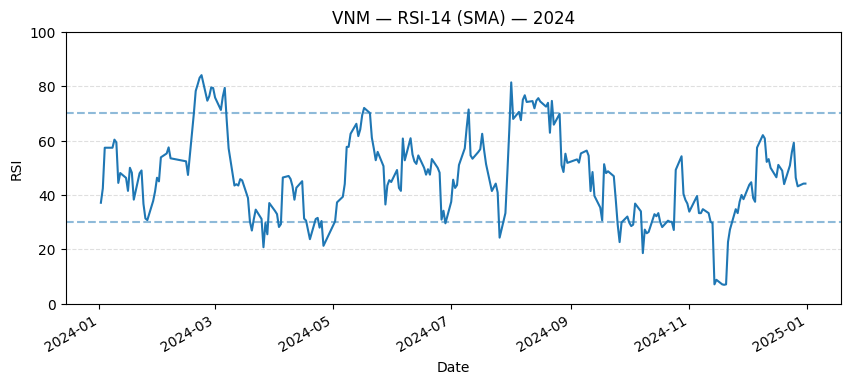

In [96]:
# --- RSI-14 (SMA) — market → preview → VNM 2024 ---
n = 14
g = prices.groupby("symbol", sort=False)

delta = g["close"].transform(lambda s: s.diff())
up    = delta.clip(lower=0)
down  = (-delta).clip(lower=0)

sma = lambda s: s.rolling(n, min_periods=n).mean()
au_s = up.groupby(prices["symbol"]).transform(sma)
ad_s = down.groupby(prices["symbol"]).transform(sma)

prices["RSI14_SMA"] = 100 - 100/(1 + (au_s / ad_s))

m = prices["RSI14_SMA"].notna()
print(prices.loc[m, ["symbol","date","RSI14_SMA"]].head(10).to_string(index=False))

sym, start, end = "VNM", "2024-01-01", "2025-01-01"
d = prices[(prices["symbol"]==sym) & (prices["date"]>=start) & (prices["date"]<end)] \
        .dropna(subset=["RSI14_SMA"]).sort_values("date")

d.plot(x="date", y="RSI14_SMA", figsize=(10,4), legend=False,
       title=f"{sym} — RSI-14 (SMA) — 2024")
plt.axhline(70, ls="--", alpha=0.5); plt.axhline(30, ls="--", alpha=0.5)
plt.ylim(0,100); plt.xlabel("Date"); plt.ylabel("RSI"); plt.grid(axis="y", ls="--", alpha=0.4)
plt.show()

## Rate of Change

The Rate of Change (ROC) measures the relative change in price compared to the price \(n\) periods ago.  
It is a momentum oscillator that oscillates around zero.

For a window length \(n\):

$$
ROC_t^{(n)} = \frac{P_t}{P_{t-n}} - 1
$$

- ROC > 0 → prices are higher than \(n\) periods ago (upward momentum).  
- ROC < 0 → prices are lower than \(n\) periods ago (downward momentum).  
- Crosses of the zero line can signal momentum shifts.

*Note:* Some charting tools multiply the formula by 100 to display percentages.  
In this notebook we keep the **ratio form** to match the SQL implementation.  
Typical setting: \(n = 14\).


symbol       date     ROC14
   BID 2014-02-24 -0.111702
   BID 2014-02-25 -0.111702
   BID 2014-02-26 -0.092391
   BID 2014-02-27 -0.051136
   BID 2014-02-28  0.018072
   BID 2014-03-03  0.000000
   BID 2014-03-04 -0.011834
   BID 2014-03-05 -0.011905
   BID 2014-03-06  0.000000
   BID 2014-03-07 -0.011905


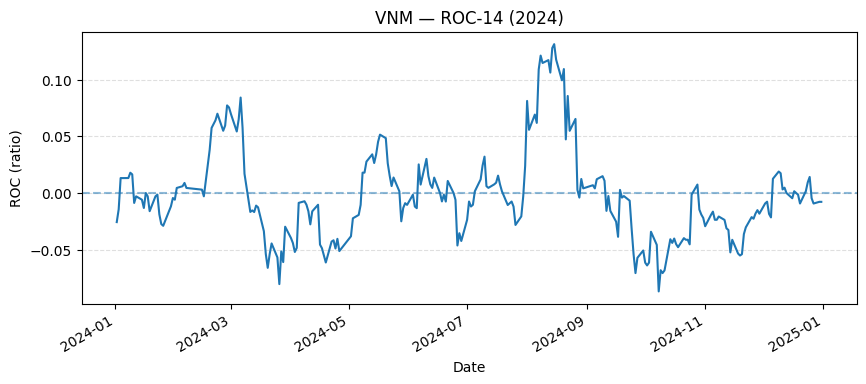

In [7]:
# --- ROC-14
n = 14
g = prices.groupby("symbol", sort=False)["close"]

prices["ROC14"] = g.transform(lambda s: (s / s.shift(n) - 1))

m = prices["ROC14"].notna()
print(prices.loc[m, ["symbol","date","ROC14"]].head(10).to_string(index=False))

sym, start, end = "VNM", "2024-01-01", "2025-01-01"
d = prices[(prices["symbol"]==sym) & (prices["date"]>=start) & (prices["date"]<end)] \
        .dropna(subset=["ROC14"]).sort_values("date")

d.plot(x="date", y="ROC14", figsize=(10,4), legend=False, title=f"{sym} — ROC-14 (2024)")
plt.axhline(0, ls="--", alpha=0.5); plt.xlabel("Date"); plt.ylabel("ROC (ratio)"); plt.grid(axis="y", ls="--", alpha=0.4)
plt.show()


## Bollinger Bands

Bollinger Bands consist of a moving average with upper and lower bands placed at a multiple of the standard deviation.  
They capture both trend and volatility.

For window length \(n = 20\) and multiplier \(k = 2\):

$$
MA_t = \frac{1}{n}\sum_{i=0}^{n-1} P_{t-i}
$$

$$
BB_{upper,t} = MA_t + k \cdot \sigma_t,
\qquad 
BB_{lower,t} = MA_t - k \cdot \sigma_t
$$

where ($sigma_t$) is the rolling standard deviation of prices.


- Price near **upper band** → potentially overbought.  
- Price near **lower band** → potentially oversold.  
- **Band squeeze** (narrow width) → low volatility, may precede breakout.  
- **Breakout**: price closes outside bands, may indicate strong directional move.  

Typical setting: \(n=20, k=2\).

symbol       date  close  BB_MA20     BB_UP     BB_LO
   BID 2014-03-03   17.0   17.090 18.492712 15.687288
   BID 2014-03-04   16.7   16.985 18.155085 15.814915
   BID 2014-03-05   16.6   16.875 17.706565 16.043435
   BID 2014-03-06   16.6   16.785 17.242275 16.327725
   BID 2014-03-07   16.6   16.735 17.005370 16.464630
   BID 2014-03-10   16.6   16.735 17.005370 16.464630
   BID 2014-03-11   16.7   16.720 16.961661 16.478339
   BID 2014-03-12   16.6   16.705 16.937164 16.472836
   BID 2014-03-13   16.5   16.690 16.934131 16.445869
   BID 2014-03-14   16.5   16.685 16.940147 16.429853


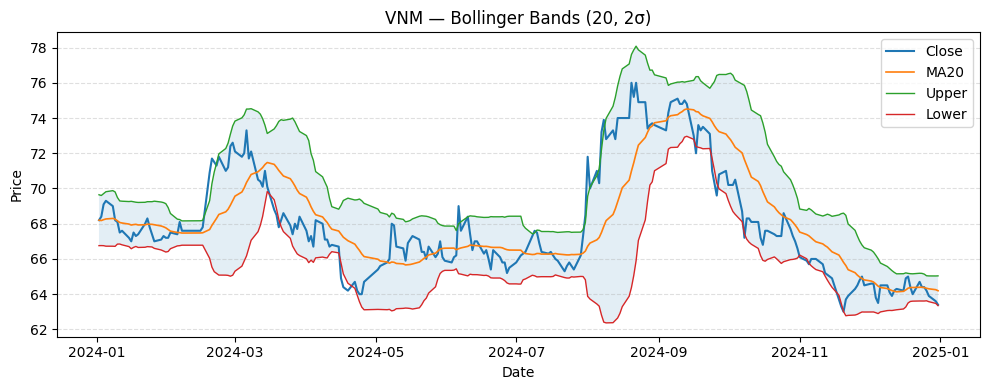

In [4]:
# --- Minimal Bollinger Bands (no squeeze/breakout) ---
SYM, START, END = "VNM", "2024-01-01", "2025-01-01"

# MA20 và độ lệch chuẩn 20 phiên (dùng population std để khớp TA phổ biến)
g = prices.groupby("symbol", sort=False)["close"]
prices["BB_MA20"] = g.transform(lambda s: s.rolling(20, min_periods=20).mean())
prices["BB_STD"]  = g.transform(lambda s: s.rolling(20, min_periods=20).std(ddof=0))
prices["BB_UP"]   = prices["BB_MA20"] + 2 * prices["BB_STD"]
prices["BB_LO"]   = prices["BB_MA20"] - 2 * prices["BB_STD"]

# Xem nhanh vài dòng đầu khi đủ dữ liệu
m = prices["BB_LO"].notna()
print(
    prices.loc[m, ["symbol","date","close","BB_MA20","BB_UP","BB_LO"]]
          .head(10).to_string(index=False)
)

# Lọc 1 mã + khung thời gian để vẽ
d = (
    prices[(prices["symbol"]==SYM) &
           (prices["date"]>=START) &
           (prices["date"]<END)]
    .dropna(subset=["BB_LO"])
)

plt.figure(figsize=(10,4))
plt.plot(d["date"], d["close"],  lw=1.5, label="Close")
plt.plot(d["date"], d["BB_MA20"], lw=1.2, label="MA20")
plt.plot(d["date"], d["BB_UP"],   lw=1.0, label="Upper")
plt.plot(d["date"], d["BB_LO"],   lw=1.0, label="Lower")
plt.fill_between(d["date"], d["BB_LO"], d["BB_UP"], alpha=0.12)
plt.title(f"{SYM} — Bollinger Bands (20, 2σ)")
plt.xlabel("Date"); plt.ylabel("Price")
plt.grid(axis="y", ls="--", alpha=0.4); plt.legend()
plt.tight_layout(); plt.show()


## Average True Range (ATR-14, Wilder)

The Average True Range (ATR) measures market volatility by averaging the True Range (TR) over a given period.  
Wilder’s smoothing method (RMA) is commonly used.

**Step 1 — True Range (TR):**

$$
TR_t = \max \Big( H_t - L_t,\; |H_t - C_{t-1}|,\; |L_t - C_{t-1}| \Big)
$$

where  
- $(H_t$): high price at time \(t\),  
- $(L_t$): low price at time \(t\),  
- $(C_{t-1}$): previous close.  

**Step 2 — Average True Range (ATR):**

Using Wilder’s recursive smoothing:

$$
ATR_t = ATR_{t-1} + \frac{1}{n}\big( TR_t - ATR_{t-1} \big)
$$

with window length \(n = 14\).
 
- Higher ATR → higher market volatility.  
- Lower ATR → calmer market conditions.  
- ATR is often used for position sizing and risk management.


symbol       date    ATR14
   BID 2014-02-21 0.678571
   BID 2014-02-24 0.651531
   BID 2014-02-25 0.619278
   BID 2014-02-26 0.596473
   BID 2014-02-27 0.603868
   BID 2014-02-28 0.582163
   BID 2014-03-03 0.562008
   BID 2014-03-04 0.557579
   BID 2014-03-05 0.532038
   BID 2014-03-06 0.508321


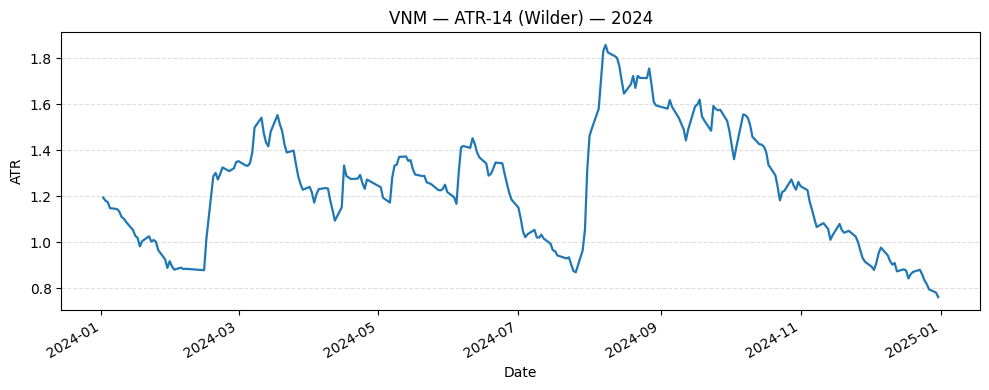

In [9]:
# --- ATR-14 (Wilder) ---
n = 14
prices = prices.sort_values(["symbol", "date"]).copy()

# True Range
prev_close = prices.groupby("symbol", sort=False)["close"].shift(1)
tr = pd.concat([
    prices["high"] - prices["low"],
    (prices["high"] - prev_close).abs(),
    (prices["low"]  - prev_close).abs()
], axis=1).max(axis=1)

# Wilder ATR function
def atr_wilder(s: pd.Series, n: int) -> pd.Series:
    x = s.to_numpy(dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    if len(x) >= n:
        out[n-1] = np.nanmean(x[:n])              # SMA seed
        for i in range(n, len(x)):
            out[i] = (out[i-1]*(n-1) + x[i]) / n  # Wilder recursion
    return pd.Series(out, index=s.index)

prices["ATR14"] = tr.groupby(prices["symbol"], sort=False).transform(lambda s: atr_wilder(s, n))
print(prices.loc[prices["ATR14"].notna(), ["symbol","date","ATR14"]]
            .head(10).to_string(index=False))

# VNM in 2024
SYM, START, END = "VNM", "2024-01-01", "2025-01-01"
d = prices[(prices["symbol"]==SYM) & (prices["date"]>=START) & (prices["date"]<END)] \
        .dropna(subset=["ATR14"])

d.plot(x="date", y="ATR14", figsize=(10,4), lw=1.6, legend=False,
       title=f"{SYM} — ATR-14 (Wilder) — 2024")
plt.xlabel("Date")
plt.ylabel("ATR")
plt.grid(axis="y", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

## On-Balance Volume (OBV)

On-Balance Volume (OBV) is a cumulative volume-based indicator that relates trading volume to price movements.  
It attempts to measure buying and selling pressure.

**Definition:**

$$
OBV_t =
\begin{cases} 
OBV_{t-1} + V_t, & \text{if } C_t > C_{t-1} \\
OBV_{t-1} - V_t, & \text{if } C_t < C_{t-1} \\
OBV_{t-1}, & \text{if } C_t = C_{t-1}
\end{cases}
$$

where  
- $(V_t$): volume at time $t$,  
- $(C_t$): closing price at time $t$.  

Rising OBV → volume confirms upward price trend (buying pressure).  
Falling OBV → volume confirms downward price trend (selling pressure).  
Divergence between OBV and price may indicate potential reversals.



In [14]:
# --- standardize volume column ---
# Find the column
vol_col = next((c for c in prices.columns if c.strip().lower() == "volume"), None)
if vol_col is None:
    raise ValueError("DataFrame không có cột 'volume' (ví dụ: 'volume', 'Volume', ...).")

# Standardize
prices.rename(columns={vol_col: "volume"}, inplace=True)
prices["volume"] = (
    prices["volume"].astype(str).str.replace(r"[^\d.]", "", regex=True)  # bỏ dấu phẩy, dấu chấm nghìn
)
prices["volume"] = pd.to_numeric(prices["volume"], errors="coerce").fillna(0)

symbol       date           OBV
   BID 2014-01-24  0.000000e+00
   BID 2014-01-27  0.000000e+00
   BID 2014-02-06 -2.784300e+08
   BID 2014-02-07 -5.809500e+08
   BID 2014-02-10 -1.474662e+10
   BID 2014-02-11 -1.085212e+10
   BID 2014-02-12 -1.111252e+10
   BID 2014-02-13 -1.144852e+10
   BID 2014-02-14 -1.229910e+10
   BID 2014-02-17 -1.173478e+10


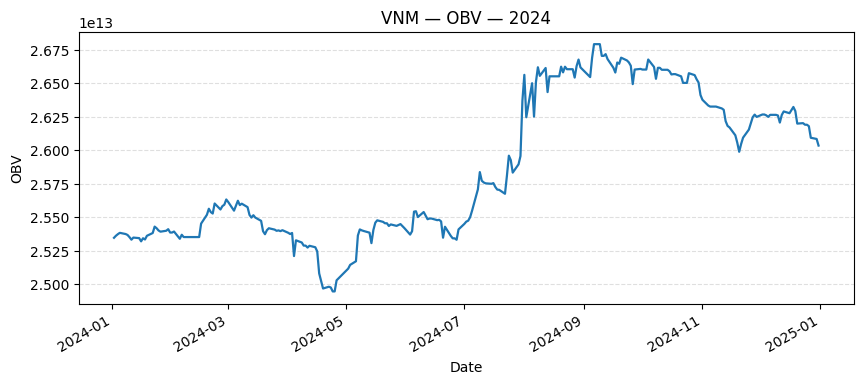

In [104]:
# --- OBV ---
g = prices.groupby("symbol", sort=False)
chg = g["close"].transform(lambda s: s.diff())
direction = np.sign(chg).fillna(0)                 # +1 / 0 / -1
prices["OBV"] = (direction * prices["volume"]).groupby(prices["symbol"]).cumsum()

m = prices["OBV"].notna()
print(prices.loc[m, ["symbol","date","OBV"]].head(10).to_string(index=False))

SYM, START, END = "VNM", "2024-01-01", "2025-01-01"
d = prices[(prices["symbol"]==SYM) & (prices["date"]>=START) & (prices["date"]<END)] \
        .dropna(subset=["OBV"]).sort_values("date")
d.plot(x="date", y="OBV", figsize=(10,4), lw=1.6, legend=False, title=f"{SYM} — OBV — 2024")
plt.xlabel("Date"); plt.ylabel("OBV"); plt.grid(axis="y", ls="--", alpha=0.4); plt.show()

## Chaikin Money Flow (CMF-20)

Chaikin Money Flow (CMF) measures the amount of Money Flow Volume over a specified period (commonly 20 days).  
It captures the relationship between price and volume to assess buying/selling pressure.

**Step 1 — Money Flow Multiplier (MFM):**

$$
MFM_t = \frac{(C_t - L_t) - (H_t - C_t)}{H_t - L_t}
= \frac{2C_t - H_t - L_t}{H_t - L_t}
$$

**where**
- $C_t$: closing price at time $t$  
- $H_t$: high price at time $t$  
- $L_t$: low price at time $t$

**Step 2 — Money Flow Volume (MFV):**

$$
MFV_t = MFM_t \times V_t
$$

with $V_t$ the volume at time $t$.

**Step 3 — Chaikin Money Flow (CMF):**

For window length $k$ (commonly $k=20$):

$$
CMF_t^{(k)} = \frac{\sum_{i=0}^{k-1} MFV_{t-i}}{\sum_{i=0}^{k-1} V_{t-i}}
$$

**Interpretation**
- $CMF > 0$ → buying pressure (accumulation)  
- $CMF < 0$ → selling pressure (distribution)  
- The farther CMF is from zero, the stronger the pressure

**Typical setting:** $k=20$.


symbol       date     CMF20
   BID 2014-03-03 -0.161369
   BID 2014-03-04  0.010173
   BID 2014-03-05 -0.002968
   BID 2014-03-06 -0.008763
   BID 2014-03-07 -0.015148
   BID 2014-03-10  0.061402
   BID 2014-03-11  0.113027
   BID 2014-03-12  0.099442
   BID 2014-03-13  0.096888
   BID 2014-03-14  0.127183


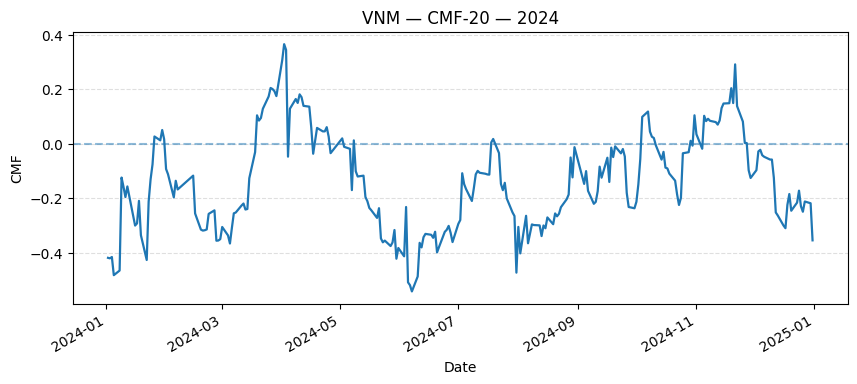

In [15]:
# --- CMF-20
k = 20

hl  = (prices["high"] - prices["low"]).replace(0, np.nan)
mfm = ((prices["close"] - prices["low"]) - (prices["high"] - prices["close"])) / hl
mfv = mfm.fillna(0) * prices["volume"]

sum_mfv = mfv.groupby(prices["symbol"]).transform(lambda s: s.rolling(k, min_periods=k).sum())
sum_vol = prices["volume"].groupby(prices["symbol"]).transform(lambda s: s.rolling(k, min_periods=k).sum())

prices["CMF20"] = sum_mfv / sum_vol

# preview + plot VNM 2024
m = prices["CMF20"].notna()
print(prices.loc[m, ["symbol","date","CMF20"]].head(10).to_string(index=False))

SYM, START, END = "VNM", "2024-01-01", "2025-01-01"
d = prices[(prices["symbol"]==SYM) & (prices["date"]>=START) & (prices["date"]<END)] \
        .dropna(subset=["CMF20"]).sort_values("date")

ax = d.plot(x="date", y="CMF20", figsize=(10,4), lw=1.6, legend=False,
            title=f"{SYM} — CMF-20 — 2024")
ax.axhline(0, ls="--", alpha=0.5)
ax.set_xlabel("Date"); ax.set_ylabel("CMF"); ax.grid(axis="y", ls="--", alpha=0.4)
plt.show()

# Backtest

In [112]:
from backtesting import Backtest, Strategy, set_bokeh_output
from backtesting.lib import crossover
from backtesting.test import SMA

# Backtesting Framework

**Execution model.** Signals are generated on close; orders execute on the same bar (`trade_on_close=True`).  
**Costs.** A transaction fee of 10 bps is applied; slippage can be added for robustness.  
**Capital.** Initial capital is 100,000,000 VND.  
**Positioning.** Long-only in these examples; sizing follows the engine defaults unless stated.

**Note.** Any open positions at the end of the sample can be finalized (`finalize_trades=True`) to include them in performance statistics.


## Strategy 1 — SMA Crossover (20, 50)

**Overview**  
This is a trend-following strategy that uses two simple moving averages to detect medium-term trends.  
The idea is that when the short-term average rises above the long-term average, the market is likely moving into an uptrend.  
When the short-term average falls below the long-term average, the uptrend is considered broken.

**Trading Rules**  
- Enter long when SMA(20) crosses above SMA(50)  
- Exit when SMA(20) crosses below SMA(50)

**Interpretation**  
The strategy captures sustained upward moves and avoids short-term noise.  
It is simple, systematic, and often used as a benchmark for trend-following systems.

In [126]:
SYMBOL    = "VNM"         # change ticker if needed
FAST_SMA  = 20            # fast SMA = 20 days
SLOW_SMA  = 50            # slow SMA = 50 days
INIT_CASH = 100_000_000   # initial capital
FEE       = 0.001         # transaction fee = 0.1%

# --- 1) Prepare data ---
data_bt = (
    prices.loc[prices["symbol"] == SYMBOL, ["date","open","high","low","close","volume"]]
          .rename(columns={
              "date":"Date","open":"Open","high":"High","low":"Low","close":"Close","volume":"Volume"
          })
          .set_index("Date")
          .sort_index()
)

# --- 2) Define SMA Cross strategy ---
class SmaCross(Strategy):
    fast = FAST_SMA
    slow = SLOW_SMA

    def init(self):
        close = self.data.Close
        self.sma_fast = self.I(SMA, close, self.fast)
        self.sma_slow = self.I(SMA, close, self.slow)

    def next(self):
        # Golden cross: fast SMA crosses above slow SMA → enter long
        if crossover(self.sma_fast, self.sma_slow):
            self.position.close()
            self.buy()
        # Death cross: fast SMA crosses below slow SMA → exit
        elif crossover(self.sma_slow, self.sma_fast):
            self.position.close()

# --- 3) Run backtest ---
bt = Backtest(
    data_bt,
    SmaCross,
    cash=INIT_CASH,
    commission=FEE,
    trade_on_close=True,
)

stats = bt.run()
display(stats)  # show performance table

# --- 4) Plot results ---
set_bokeh_output(notebook=True)
bt.plot(open_browser=False)


Backtest.run:   0%|          | 0/4865 [00:00<?, ?bar/s]

C:\Users\Nguyen Thao\AppData\Local\Temp\ipykernel_3192\4183392192.py:45: UserWarning:

Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.



Start                     2006-01-19 00:00:00
End                       2025-10-03 00:00:00
Duration                   7197 days 00:00:00
Exposure Time [%]                     48.3825
Equity Final [$]              122050721.60604
Equity Peak [$]                 240003508.756
Commissions [$]                12568562.36576
Return [%]                           22.05072
Buy & Hold Return [%]               -24.32099
Return (Ann.) [%]                     1.02691
Volatility (Ann.) [%]                27.23538
CAGR [%]                              0.70016
Sharpe Ratio                           0.0377
Sortino Ratio                         0.04728
Calmar Ratio                           0.0157
Alpha [%]                            38.29073
Beta                                  0.66774
Max. Drawdown [%]                   -65.41108
Avg. Drawdown [%]                     -14.067
Max. Drawdown Duration     6792 days 00:00:00
Avg. Drawdown Duration      772 days 00:00:00
# Trades                          

GridPlot(id='p4892', ...)

## Strategy 2 — RSI Mean Reversion (RSI-14, Buy <30 / Exit >70)

**Overview**  
This is a mean-reversion strategy that uses the Relative Strength Index (RSI) to find oversold and overbought conditions.  
The idea is that prices tend to rebound after extreme declines and lose momentum after strong rallies.

**Trading Rules**  
- Enter long when RSI(14) < 30 (oversold)  
- Exit when RSI(14) > 70 (overbought)

**Interpretation**  
The strategy works well in sideways or range-bound markets where reversals are common.  
It performs poorly in strong trending markets because RSI can stay oversold or overbought for extended periods.


In [115]:
class RsiMeanRevert(Strategy):
    rsi_len = 14   # độ dài RSI
    os = 30        # oversold  -> tín hiệu mua
    ob = 70        # overbought -> thoát vị thế

    def init(self):
        close = self.data.Close

        # RSI Wilder, vectorized để dùng với self.I
        def rsi_wilder(arr, n=self.rsi_len):
            s = pd.Series(arr)
            delta = s.diff()
            up = delta.clip(lower=0)
            dn = (-delta).clip(lower=0)
            alpha = 1/n
            roll_up = up.ewm(alpha=alpha, adjust=False, min_periods=n).mean()
            roll_dn = dn.ewm(alpha=alpha, adjust=False, min_periods=n).mean()
            rs = roll_up / roll_dn
            rsi = 100 - (100/(1+rs))
            return rsi.values

        self.rsi = self.I(rsi_wilder, close)

    def next(self):
        r = self.rsi[-1]

        # Mua khi quá bán
        if r < self.os and not self.position.is_long:
            self.position.close()
            self.buy()

        # Thoát khi quá mua
        elif r > self.ob and self.position.is_long:
            self.position.close()
bt2 = Backtest(
    data_bt,
    RsiMeanRevert,
    cash=100_000_000,
    commission=0.001,
    trade_on_close=True
)
stats2 = bt2.run()
display(stats2)
bt2.plot(open_browser=False)

Backtest.run:   0%|          | 0/4900 [00:00<?, ?bar/s]

Start                     2006-01-19 00:00:00
End                       2025-10-03 00:00:00
Duration                   7197 days 00:00:00
Exposure Time [%]                    49.07426
Equity Final [$]              221554675.52626
Equity Peak [$]               305171393.27226
Commissions [$]                 9684289.73374
Return [%]                          121.55468
Buy & Hold Return [%]                11.45455
Return (Ann.) [%]                     4.16297
Volatility (Ann.) [%]                20.81483
CAGR [%]                              2.82456
Sharpe Ratio                              0.2
Sortino Ratio                         0.31013
Calmar Ratio                          0.08515
Alpha [%]                           118.09637
Beta                                  0.30192
Max. Drawdown [%]                   -48.89046
Avg. Drawdown [%]                   -10.10334
Max. Drawdown Duration     1702 days 00:00:00
Avg. Drawdown Duration      242 days 00:00:00
# Trades                          

GridPlot(id='p1766', ...)

## Strategy 3 — Bollinger Bands Breakout (MA20 ± 2σ)

**Overview**  
This is a volatility breakout strategy that uses Bollinger Bands to identify large price movements.  
The bands are built from a 20-day moving average and two standard deviations.  
When the price closes outside the bands, it suggests that volatility is expanding and a strong move may follow.

**Trading Rules**  
- Enter long when Close > Upper Band  
- Exit when Close < MA20 (default)  
- Exit when Close < Lower Band (if lower-exit option is used)

**Interpretation**  
The strategy aims to capture breakouts after periods of low volatility.  
Using MA20 as exit makes trades shorter and more reactive.  
Using the lower band as exit holds trades longer but increases risk.


In [116]:
class BBreakout(Strategy):
    window = 20     # MA20
    nstd   = 2.0    # ±2σ
    use_lower_exit = False  # True: thoát khi < BB Lower; False: thoát khi < MA20

    def init(self):
        close = self.data.Close

        def bbands(arr, window=self.window, nstd=self.nstd):
            s = pd.Series(arr)
            ma = s.rolling(window, min_periods=window).mean()
            sd = s.rolling(window, min_periods=window).std(ddof=0)
            upper = ma + nstd * sd
            lower = ma - nstd * sd
            return np.vstack([ma.values, upper.values, lower.values])

        # Register indicators: returns 3 rows -> MA, Upper, Lower
        self.bb_ma, self.bb_up, self.bb_lo = self.I(bbands, close, name='BB')

    def next(self):
        c  = self.data.Close[-1]
        ma = self.bb_ma[-1]
        up = self.bb_up[-1]
        lo = self.bb_lo[-1]

        # Entry: breakout lên trên dải trên
        if c > up and not self.position.is_long:
            self.position.close()
            self.buy()

        # Exit: đóng dưới MA20 (hoặc BB Lower nếu bật)
        if self.position.is_long:
            if (not self.use_lower_exit and c < ma) or (self.use_lower_exit and c < lo):
                self.position.close()

# ---- RUN trên data_bt (index=Date, cột: Open, High, Low, Close, Volume) ----
bt3 = Backtest(
    data_bt,
    BBreakout,
    cash=100_000_000,
    commission=0.001,
    trade_on_close=True
)
stats3 = bt3.run()
display(stats3)
bt3.plot(open_browser=False)


Backtest.run:   0%|          | 0/4895 [00:00<?, ?bar/s]

Start                     2006-01-19 00:00:00
End                       2025-10-03 00:00:00
Duration                   7197 days 00:00:00
Exposure Time [%]                    29.52187
Equity Final [$]              127167692.48862
Equity Peak [$]                254817667.6555
Commissions [$]                23849168.89138
Return [%]                           27.16769
Buy & Hold Return [%]                -2.69841
Return (Ann.) [%]                     1.23987
Volatility (Ann.) [%]                21.24183
CAGR [%]                              0.84508
Sharpe Ratio                          0.05837
Sortino Ratio                         0.07324
Calmar Ratio                          0.02087
Alpha [%]                             28.2913
Beta                                   0.4164
Max. Drawdown [%]                   -59.39569
Avg. Drawdown [%]                   -13.80763
Max. Drawdown Duration     5884 days 00:00:00
Avg. Drawdown Duration      648 days 00:00:00
# Trades                          

GridPlot(id='p2153', ...)

## Strategy 4 — OBV Crossover with Price-MA Filter

**Overview**  
This strategy combines the On-Balance Volume (OBV) indicator with a moving average filter on price.  
It assumes that a bullish signal is more reliable when both volume flow and price trend confirm each other.

**Trading Rules**  
- Enter long when OBV crosses above its 20-day average and Close > SMA(20) (if filter is active)  
- Exit when OBV crosses below its average  
- Exit when Close < SMA(20) (if filter is active)

**Interpretation**  
The strategy uses OBV to measure buying pressure and the price filter to confirm trend direction.  
This reduces false signals and aligns trades with both volume and price momentum.


In [117]:
# ===== OBV crossover (kèm price-MA filter) =====
class OBVTrend(Strategy):
    obv_ma_win = 20      # SMA của OBV
    price_ma_win = 20    # SMA của giá để làm filter
    require_price_ma = True  # True: chỉ mua khi giá > MA

    def init(self):
        close = self.data.Close
        vol   = self.data.Volume

        def obv_and_ma(close, volume, n):
            c = pd.Series(close)
            v = pd.Series(volume)
            # OBV = cum( sign(ΔClose) * Volume )
            sign = np.sign(c.diff()).fillna(0)
            obv = (sign * v).cumsum()
            obv_ma = obv.rolling(n, min_periods=n).mean()
            # trả 2 hàng: OBV, OBV_MA
            return np.vstack([obv.values, obv_ma.values])

        # Đăng ký: self.obv, self.obv_ma
        self.obv, self.obv_ma = self.I(obv_and_ma, close, vol, self.obv_ma_win, name='OBV')

        def sma(arr, n):
            return pd.Series(arr).rolling(n, min_periods=n).mean().values

        self.pma = self.I(sma, close, self.price_ma_win)  # price MA để lọc

    def next(self):
        c   = self.data.Close[-1]
        obv = self.obv[-1];     obv_prev = self.obv[-2]
        oma = self.obv_ma[-1];  oma_prev = self.obv_ma[-2]

        cross_up   = obv > oma and obv_prev <= oma_prev
        cross_down = obv < oma and obv_prev >= oma_prev

        ok_price = True
        if self.require_price_ma:
            ok_price = c > self.pma[-1]

        # Entry
        if cross_up and ok_price and not self.position.is_long:
            self.position.close()
            self.buy()

        # Exit
        if self.position.is_long and (cross_down or (self.require_price_ma and c < self.pma[-1])):
            self.position.close()
bt_obv = Backtest(
    data_bt,          # index=Date, cột: Open, High, Low, Close, Volume
    OBVTrend,
    cash=100_000_000,
    commission=0.001,
    trade_on_close=True
)
stats_obv = bt_obv.run()
display(stats_obv)
bt_obv.plot(open_browser=False)


Backtest.run:   0%|          | 0/4895 [00:00<?, ?bar/s]

Start                     2006-01-19 00:00:00
End                       2025-10-03 00:00:00
Duration                   7197 days 00:00:00
Exposure Time [%]                    18.10783
Equity Final [$]               91123206.09824
Equity Peak [$]                 115409852.479
Commissions [$]                17520036.06176
Return [%]                           -8.87679
Buy & Hold Return [%]                -2.69841
Return (Ann.) [%]                    -0.47548
Volatility (Ann.) [%]                11.49421
CAGR [%]                             -0.32496
Sharpe Ratio                         -0.04137
Sortino Ratio                        -0.05378
Calmar Ratio                         -0.01491
Alpha [%]                            -8.58539
Beta                                  0.10799
Max. Drawdown [%]                   -31.89481
Avg. Drawdown [%]                   -18.78644
Max. Drawdown Duration     4218 days 00:00:00
Avg. Drawdown Duration     1437 days 00:00:00
# Trades                          

GridPlot(id='p2582', ...)